# Variable Construction: Extending the B&C (2011) Dataset to 2024

## Overview

This notebook constructs updated versions of the three core variables from
Brückner & Ciccone (2011), *"Rain and the Democratic Window of Opportunity"*
(*Econometrica*, 79(3): 923–947), extending coverage from 2005 to the most
recent year available for each source.

| Variable | Original (B&C) | Extended to | Source |
|---|---|---|---|
| Democracy (Polity2 & subscores) | 1981–2004 | 2005–2024 | Polity V (2005–2018); V-Dem v16 rescaled (2019–2024) |
| Real GDP per capita | 1981–2004 | 2005–2023 | Penn World Table 11.0 |
| Rainfall (GPCP) | 1981–2004 | 2005–2024 | NASA GPCP v2.3 |

**Output:** `data/processed/panel_final.csv` — a single 41-country panel
(1981–2024) ready for replication analysis (see `replication_analysis.ipynb`).


In [1]:
import pandas as pd
import numpy as np
import os

# ── Load original Brückner & Ciccone (2011) dataset ─────────────────────────
# This Stata file contains all variables for 41 SSA countries, 1981–2004.
# We use it to (1) identify the exact 41-country sample, and (2) anchor
# the first change variable for 2005 (which requires the 2004 level).
database = pd.read_stata("data/raw/original/database.dta")
print(f"Original database: {len(database):,} rows, {database['year'].min()}–{database['year'].max()}")

# ── Build reference table: 41 SSA countries with ccode + iso3 ───────────────
# ccode  = numeric Polity country code (used to match p5v2018.xlsx reliably)
# iso3   = 3-letter ISO code used throughout the rest of this notebook
country_ref = (
    database[['country', 'countryisocode', 'ccode']]
    .drop_duplicates()
    .dropna(subset=['ccode'])
    .rename(columns={'countryisocode': 'iso3'})
    .sort_values('country')
    .reset_index(drop=True)
)

# Ethiopia exception: original database uses ccode 530 (pre-1993 split),
# but p5v2018 uses ccode 529 for post-split Ethiopia (scode='ETI').
# We map 529 → 530 when merging so Ethiopia is captured correctly.
ETHIOPIA_P5_CCODE  = 529   # ccode in p5v2018 for post-1993 Ethiopia
ETHIOPIA_ORIG_CCODE = 530  # ccode in original database for Ethiopia

print(f"\nSSA sample: {len(country_ref)} countries")
print(country_ref.to_string(index=False))


Original database: 961 rows, 1981–2004

SSA sample: 41 countries
                 country iso3  ccode
                  Angola  AGO    540
                   Benin  BEN    434
                Botswana  BWA    571
            Burkina Faso  BFA    439
                 Burundi  BDI    516
                Cameroon  CMR    471
Central African Republic  CAF    482
                    Chad  TCD    483
        Congo, Dem. Rep.  ZAR    490
      Congo, Republic of  COG    484
           Cote d`Ivoire  CIV    437
                Djibouti  DJI    522
                Ethiopia  ETH    530
                   Gabon  GAB    481
             Gambia, The  GMB    420
                   Ghana  GHA    452
                  Guinea  GIN    438
           Guinea-Bissau  GNB    404
                   Kenya  KEN    501
                 Lesotho  LSO    570
                 Liberia  LBR    450
              Madagascar  MDG    580
                  Malawi  MWI    553
                    Mali  MLI    432
          

## Part 1: Democracy Extension — Polity V (2005–2018)

### Step 1: Load and Clean Polity V Data

**Challenge:** Matching countries across datasets requires care:

1. **Ethiopia ccode mismatch** — Eritrea's independence (1993) caused p5v2018 to assign
   a new ccode (529) to the post-split Ethiopia, while the original B&C database retains
   the pre-split ccode (530). We remap 529 → 530 to preserve continuity.

2. **Special codes** — Four country-years have Polity special codes (−77) in sub-scores
   (Central African Republic 2013–2015, Mali 2012). We treat these as missing values.


In [2]:
# ── Load Polity V source file ────────────────────────────────────────────────
p5_raw = pd.read_excel("data/raw/polity/p5v2018.xlsx")
print(f"p5v2018.xlsx loaded: {len(p5_raw):,} rows, {p5_raw['year'].min()}–{p5_raw['year'].max()}")

# ── Remap Ethiopia ccode so it matches the original database ─────────────────
p5_raw['ccode'] = p5_raw['ccode'].replace(ETHIOPIA_P5_CCODE, ETHIOPIA_ORIG_CCODE)

# ── Filter to 41 SSA countries and 2005–2018 ─────────────────────────────────
ssa_ccodes = set(country_ref['ccode'])
p5 = (
    p5_raw[
        p5_raw['ccode'].isin(ssa_ccodes) &
        p5_raw['year'].between(2005, 2018)
    ]
    [['ccode', 'year', 'polity2', 'exconst', 'polcomp', 'exrec']]
    .copy()
    .reset_index(drop=True)
)

# ── Merge in iso3 and country name from reference table ──────────────────────
p5 = p5.merge(country_ref[['ccode', 'iso3', 'country']], on='ccode', how='left')

# ── Clean special Polity codes: −66 (interregnum), −77 (transition) → NaN ───
# These codes appear in sub-score columns (exconst, polcomp, exrec) and
# represent periods where normal scoring cannot be applied.
SPECIAL_CODES = [-66, -77]
for col in ['exconst', 'polcomp', 'exrec']:
    n_special = p5[col].isin(SPECIAL_CODES).sum()
    if n_special > 0:
        affected = p5[p5[col].isin(SPECIAL_CODES)][['country', 'year', col]]
        print(f"  {col}: {n_special} special-code rows → set to NaN")
        print(affected.to_string(index=False))
    p5.loc[p5[col].isin(SPECIAL_CODES), col] = np.nan

# polity2 uses -66/-77 differently; B&C filter these via `if polity!=-77`
n_p2_special = p5['polity2'].isin(SPECIAL_CODES).sum()
if n_p2_special > 0:
    print(f"  polity2: {n_p2_special} special-code rows → set to NaN")
    p5.loc[p5['polity2'].isin(SPECIAL_CODES), 'polity2'] = np.nan

print(f"\nFiltered Polity V panel: {len(p5)} rows")
print(f"Countries: {p5['iso3'].nunique()} | Years: {p5['year'].min()}–{p5['year'].max()}")
print()
print(p5[['iso3', 'country', 'year', 'polity2', 'exconst', 'polcomp', 'exrec']].head(10).to_string(index=False))


p5v2018.xlsx loaded: 17,574 rows, 1776–2020
  exconst: 14 special-code rows → set to NaN
                 country  year  exconst
Central African Republic  2013      -77
Central African Republic  2014      -77
Central African Republic  2015      -77
           Cote d`Ivoire  2005      -77
           Cote d`Ivoire  2006      -77
           Cote d`Ivoire  2010      -77
                    Mali  2012      -77
                 Somalia  2005      -77
                 Somalia  2006      -77
                 Somalia  2007      -77
                 Somalia  2008      -77
                 Somalia  2009      -77
                 Somalia  2010      -77
                 Somalia  2011      -66
  polcomp: 14 special-code rows → set to NaN
                 country  year  polcomp
Central African Republic  2013    -77.0
Central African Republic  2014    -77.0
Central African Republic  2015    -77.0
           Cote d`Ivoire  2005    -77.0
           Cote d`Ivoire  2006    -77.0
           Cote d`Ivoire  

### Step 2: Construct Year-on-Year Change Variables

The paper's dependent variable is the **year-on-year change** in each democracy score:

> `polity_change_t = polity2_t − polity2_{t−1}`

and analogously for `exconst_change`, `polcomp_change`, `exrec_change`.

To compute the change for **2005** (the first extension year), we need the **2004 level**,
which comes from the original `database.dta`. We prepend the 2004 rows as an anchor,
compute the differences, then drop the 2004 anchor.


In [3]:
# ── Extract 2004 anchor rows from original database ──────────────────────────
# Needed to compute polity_change for 2005 = polity2_2005 − polity2_2004
anchor_2004 = (
    database[database['year'] == 2004]
    [['countryisocode', 'polity2', 'exconst', 'polcomp', 'exrec']]
    .rename(columns={'countryisocode': 'iso3'})
    .assign(year=2004,
            ccode=database[database['year']==2004]['ccode'].values,
            country=database[database['year']==2004]['country'].values)
    .reset_index(drop=True)
)

# ── Stack anchor + extension, sort within each country ───────────────────────
p5_full = (
    pd.concat([anchor_2004, p5], ignore_index=True)
    .sort_values(['iso3', 'year'])
    .reset_index(drop=True)
)

# ── Compute change variables as backward differences within each country ──────
for var, chg in [('polity2', 'polity_change'),
                 ('exconst', 'exconst_change'),
                 ('polcomp', 'polcomp_change'),
                 ('exrec',   'exrec_change')]:
    p5_full[chg] = p5_full.groupby('iso3')[var].diff()

# ── Drop the 2004 anchor (it was only needed for computing 2005 changes) ──────
polity_ext = p5_full[p5_full['year'] >= 2005].reset_index(drop=True)

# ── Final column order ────────────────────────────────────────────────────────
col_order = ['iso3', 'country', 'year',
             'polity2', 'polity_change',
             'exconst', 'exconst_change',
             'polcomp', 'polcomp_change',
             'exrec',   'exrec_change']
polity_ext = polity_ext[col_order]

# ── Save ──────────────────────────────────────────────────────────────────────
os.makedirs('data/processed', exist_ok=True)
polity_ext.to_csv('data/processed/democracy_polity2_extended_2005_2018.csv', index=False)

# ── Validation ────────────────────────────────────────────────────────────────
print(f"Saved: data/processed/democracy_polity2_extended_2005_2018.csv")
print(f"Rows: {len(polity_ext)} | Countries: {polity_ext['iso3'].nunique()} | Years: 2005–2018")
print()
print("Sample (Nigeria):")
print(polity_ext[polity_ext['iso3']=='NGA'].to_string(index=False))
print()
print("Missing values per column:")
print(polity_ext.isnull().sum().to_string())


Saved: data/processed/democracy_polity2_extended_2005_2018.csv
Rows: 567 | Countries: 41 | Years: 2005–2018

Sample (Nigeria):
iso3 country  year  polity2  polity_change  exconst  exconst_change  polcomp  polcomp_change  exrec  exrec_change
 NGA Nigeria  2005      4.0            0.0      5.0             0.0      5.0             0.0    7.0           0.0
 NGA Nigeria  2006      4.0            0.0      5.0             0.0      5.0             0.0    7.0           0.0
 NGA Nigeria  2007      4.0            0.0      5.0             0.0      5.0             0.0    7.0           0.0
 NGA Nigeria  2008      4.0            0.0      5.0             0.0      5.0             0.0    7.0           0.0
 NGA Nigeria  2009      4.0            0.0      5.0             0.0      5.0             0.0    7.0           0.0
 NGA Nigeria  2010      4.0            0.0      5.0             0.0      5.0             0.0    7.0           0.0
 NGA Nigeria  2011      4.0            0.0      5.0             0.0      5.

## Part 1 (cont.): Extend Democracy to 2019–2024 via Rescaled V-Dem

Polity V officially ends at **2018** (`p5v2018` release). To extend through 2024 we use the
**Varieties of Democracy (V-Dem) dataset** (v16), which covers 1789–2025.

Since the paper's dependent variable is the *change* in Polity2, we rescale V-Dem's
Electoral Democracy Index (`v2x_polyarchy`) so that its annual change has the same
standard deviation as ΔPolity2 over the 1982–2018 overlap period.

The table below shows the V-Dem analogues used for each Polity component:

| Polity component | V-Dem analogue |
|---|---|
| Polity2 | `v2x_polyarchy` (Electoral Democracy Index) |
| Exconst | `v2xlg_legcon` (legislative constraints on executive) |
| Polcomp | `v2xel_frefair` (free and fair elections) |
| Exrec | `v2xel_frefair` (same) |


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

# ── Load V-Dem (extracted from R vdemdata package) ──────────────────────────
vdem = pd.read_csv("data/processed/vdem_ssa_1980_2025.csv")

# Map V-Dem iso3 (uses COD for DR Congo) back to original database code (ZAR)
vdem['iso3'] = vdem['iso3'].replace({'COD': 'ZAR'})

print(f"V-Dem rows: {len(vdem)}")
print(f"Countries : {vdem['iso3'].nunique()}")
print(f"Years     : {vdem['year'].min()} – {vdem['year'].max()}")
print()
print(vdem.head(5).to_string(index=False))


V-Dem rows: 1886
Countries : 41
Years     : 1980 – 2025

country_name iso3  year  v2x_polyarchy  v2x_libdem  v2xlg_legcon  v2x_jucon  v2xps_party  v2x_elecoff  v2xel_frefair
      Angola  AGO  1980          0.073       0.045         0.069      0.302        0.248          0.0            0.0
      Angola  AGO  1981          0.073       0.045         0.069      0.302        0.248          0.0            0.0
      Angola  AGO  1982          0.073       0.045         0.069      0.302        0.248          0.0            0.0
      Angola  AGO  1983          0.073       0.045         0.069      0.302        0.248          0.0            0.0
      Angola  AGO  1984          0.073       0.045         0.069      0.302        0.248          0.0            0.0


In [5]:
# ── Build full Polity panel (1981–2018) for V-Dem comparison ─────────────────
# For the correlation analysis we want the full overlap period with V-Dem (1980–2018).
# • 1981–2004: levels come directly from the original database.dta
# • 2005–2018: from our newly constructed extension CSV

# Extract levels from original database (1981-2004)
polity_orig = (
    database[database['year'].between(1981, 2004)]
    [['country', 'countryisocode', 'year', 'polity2', 'exconst', 'polcomp', 'exrec']]
    .rename(columns={'countryisocode': 'iso3'})
    .copy()
)

# Load the 2005-2018 extension (already cleaned and with iso3)
polity_ext_loaded = pd.read_csv("data/processed/democracy_polity2_extended_2005_2018.csv")

# Stack into a single 1981-2018 panel
polity_full = pd.concat([
    polity_orig[['iso3', 'country', 'year', 'polity2', 'exconst', 'polcomp', 'exrec']],
    polity_ext_loaded[['iso3', 'country', 'year', 'polity2', 'exconst', 'polcomp', 'exrec']]
], ignore_index=True).sort_values(['iso3', 'year']).reset_index(drop=True)

# Clean special Polity codes from the 1981-2004 portion as well
for col in ['polity2', 'exconst', 'polcomp', 'exrec']:
    polity_full.loc[polity_full[col].isin([-66, -77]), col] = np.nan

# ── Merge with V-Dem on iso3 + year ──────────────────────────────────────────
merged = polity_full.merge(
    vdem[['iso3', 'year', 'v2x_polyarchy', 'v2x_libdem',
          'v2xlg_legcon', 'v2x_jucon', 'v2xps_party', 'v2x_elecoff', 'v2xel_frefair']],
    on=['iso3', 'year'], how='inner'
).dropna(subset=['polity2', 'v2x_polyarchy'])

print(f"Overlap sample: {len(merged)} obs, {merged['iso3'].nunique()} countries, "
      f"{merged['year'].min()}–{merged['year'].max()}")
print()

# ── Compute Pearson and Spearman correlations ─────────────────────────────────
pairs = [
    ('polity2',  'v2x_polyarchy',  'Polity2 ↔ v2x_polyarchy (Electoral Democracy)'),
    ('polity2',  'v2x_libdem',     'Polity2 ↔ v2x_libdem (Liberal Democracy)'),
    ('exconst',  'v2xlg_legcon',   'Exconst ↔ v2xlg_legcon (Legislative Constraints)'),
    ('exconst',  'v2x_jucon',      'Exconst ↔ v2x_jucon (Judicial Constraints)'),
    ('polcomp',  'v2xel_frefair',  'Polcomp ↔ v2xel_frefair (Free & Fair Elections)'),
    ('polcomp',  'v2xps_party',    'Polcomp ↔ v2xps_party (Party Institutionalization)'),
    ('exrec',    'v2xel_frefair',  'Exrec   ↔ v2xel_frefair (Free & Fair Elections)'),
    ('exrec',    'v2x_elecoff',    'Exrec   ↔ v2x_elecoff (Elected Officials)'),
]

print(f"{'Pair':<52} {'Pearson r':>10} {'Spearman ρ':>11}  N")
print("-" * 80)
for pv, vv, label in pairs:
    sub = merged[[pv, vv]].dropna()
    if len(sub) < 10:
        print(f"{label:<52} {'—':>10} {'—':>11}  {len(sub)}")
        continue
    r,  _ = stats.pearsonr(sub[pv],  sub[vv])
    rs, _ = stats.spearmanr(sub[pv], sub[vv])
    print(f"{label:<52} {r:>10.3f} {rs:>11.3f}  {len(sub)}")


Overlap sample: 1417 obs, 41 countries, 1981–2018

Pair                                                  Pearson r  Spearman ρ  N
--------------------------------------------------------------------------------
Polity2 ↔ v2x_polyarchy (Electoral Democracy)             0.817       0.821  1417
Polity2 ↔ v2x_libdem (Liberal Democracy)                  0.769       0.758  1417
Exconst ↔ v2xlg_legcon (Legislative Constraints)          0.630       0.623  1326
Exconst ↔ v2x_jucon (Judicial Constraints)                0.532       0.509  1368
Polcomp ↔ v2xel_frefair (Free & Fair Elections)           0.659       0.670  1368
Polcomp ↔ v2xps_party (Party Institutionalization)        0.407       0.388  1261
Exrec   ↔ v2xel_frefair (Free & Fair Elections)           0.620       0.585  1368
Exrec   ↔ v2x_elecoff (Elected Officials)                 0.395       0.273  1368


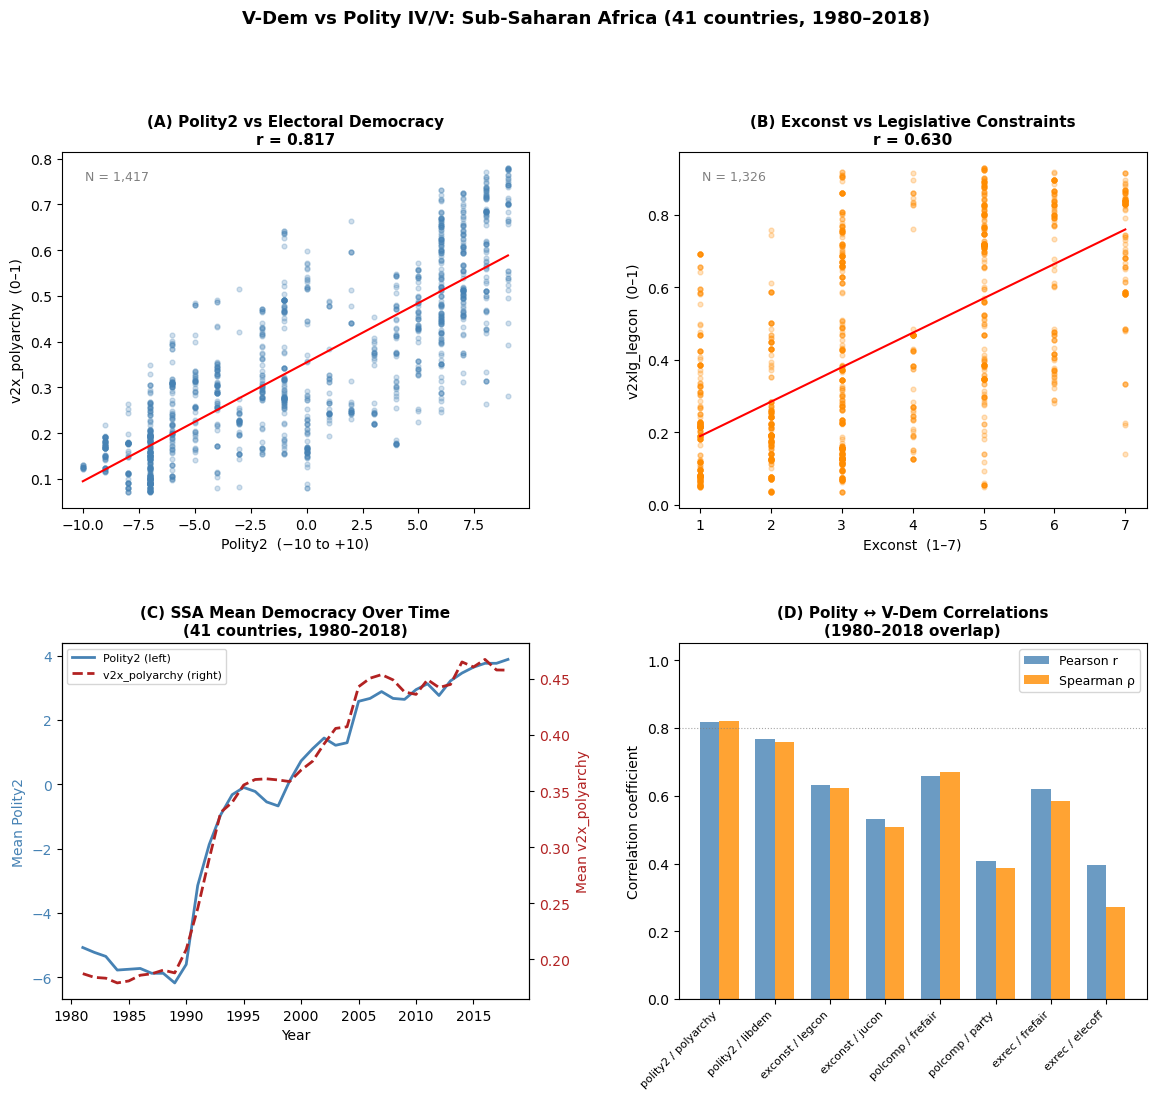

✅ Figure saved: data/processed/vdem_vs_polity_comparison.png


In [6]:
# ── 4-panel comparison figure: V-Dem vs Polity ──────────────────────────────
fig = plt.figure(figsize=(14, 11))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

# ── Panel A: Polity2 vs v2x_polyarchy scatter ────────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
sub_a = merged[['polity2', 'v2x_polyarchy']].dropna()
r_a, _ = stats.pearsonr(sub_a['polity2'], sub_a['v2x_polyarchy'])
ax_a.scatter(sub_a['polity2'], sub_a['v2x_polyarchy'],
             alpha=0.25, s=12, color='steelblue', rasterized=True)
m, b = np.polyfit(sub_a['polity2'], sub_a['v2x_polyarchy'], 1)
xs = np.linspace(sub_a['polity2'].min(), sub_a['polity2'].max(), 100)
ax_a.plot(xs, m*xs + b, 'r-', lw=1.5)
ax_a.set_xlabel('Polity2  (−10 to +10)', fontsize=10)
ax_a.set_ylabel('v2x_polyarchy  (0–1)', fontsize=10)
ax_a.set_title(f'(A) Polity2 vs Electoral Democracy\nr = {r_a:.3f}', fontsize=11, fontweight='bold')
ax_a.text(0.05, 0.92, f'N = {len(sub_a):,}', transform=ax_a.transAxes, fontsize=9, color='gray')

# ── Panel B: Exconst vs v2xlg_legcon scatter ────────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
sub_b = merged[['exconst', 'v2xlg_legcon']].dropna()
r_b, _ = stats.pearsonr(sub_b['exconst'], sub_b['v2xlg_legcon'])
ax_b.scatter(sub_b['exconst'], sub_b['v2xlg_legcon'],
             alpha=0.25, s=12, color='darkorange', rasterized=True)
m, b = np.polyfit(sub_b['exconst'], sub_b['v2xlg_legcon'], 1)
xs = np.linspace(sub_b['exconst'].min(), sub_b['exconst'].max(), 100)
ax_b.plot(xs, m*xs + b, 'r-', lw=1.5)
ax_b.set_xlabel('Exconst  (1–7)', fontsize=10)
ax_b.set_ylabel('v2xlg_legcon  (0–1)', fontsize=10)
ax_b.set_title(f'(B) Exconst vs Legislative Constraints\nr = {r_b:.3f}', fontsize=11, fontweight='bold')
ax_b.text(0.05, 0.92, f'N = {len(sub_b):,}', transform=ax_b.transAxes, fontsize=9, color='gray')

# ── Panel C: SSA mean time series ──────────────────────────────────────────
ax_c = fig.add_subplot(gs[1, 0])
ts_polity = merged.groupby('year')['polity2'].mean()
ts_vdem   = merged.groupby('year')['v2x_polyarchy'].mean()

color_p = 'steelblue'
color_v = 'firebrick'
ax_c.plot(ts_polity.index, ts_polity.values, color=color_p, lw=2, label='Polity2 (left)')
ax_c.set_ylabel('Mean Polity2', color=color_p, fontsize=10)
ax_c.tick_params(axis='y', labelcolor=color_p)

ax_c2 = ax_c.twinx()
ax_c2.plot(ts_vdem.index, ts_vdem.values, color=color_v, lw=2,
           linestyle='--', label='v2x_polyarchy (right)')
ax_c2.set_ylabel('Mean v2x_polyarchy', color=color_v, fontsize=10)
ax_c2.tick_params(axis='y', labelcolor=color_v)

lines1, labels1 = ax_c.get_legend_handles_labels()
lines2, labels2 = ax_c2.get_legend_handles_labels()
ax_c.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')
ax_c.set_title('(C) SSA Mean Democracy Over Time\n(41 countries, 1980–2018)',
               fontsize=11, fontweight='bold')
ax_c.set_xlabel('Year', fontsize=10)

# ── Panel D: Correlation bar chart ─────────────────────────────────────────
ax_d = fig.add_subplot(gs[1, 1])
bar_labels = [
    'polity2 / polyarchy', 'polity2 / libdem',
    'exconst / legcon',    'exconst / jucon',
    'polcomp / frefair',   'polcomp / party',
    'exrec / frefair',     'exrec / elecoff',
]
pearson_r = []
spearman_r = []
for pv, vv, _ in pairs:
    sub = merged[[pv, vv]].dropna()
    if len(sub) >= 10:
        pearson_r.append(stats.pearsonr(sub[pv],  sub[vv])[0])
        spearman_r.append(stats.spearmanr(sub[pv], sub[vv])[0])
    else:
        pearson_r.append(0)
        spearman_r.append(0)

x = np.arange(len(bar_labels))
w = 0.35
ax_d.bar(x - w/2, pearson_r,  w, label='Pearson r',  color='steelblue',  alpha=0.8)
ax_d.bar(x + w/2, spearman_r, w, label='Spearman ρ', color='darkorange', alpha=0.8)
ax_d.axhline(0, color='black', lw=0.8)
ax_d.axhline(0.8, color='gray', lw=0.8, linestyle=':', alpha=0.7)
ax_d.set_xticks(x)
ax_d.set_xticklabels(bar_labels, rotation=45, ha='right', fontsize=8)
ax_d.set_ylabel('Correlation coefficient', fontsize=10)
ax_d.set_ylim(0, 1.05)
ax_d.set_title('(D) Polity ↔ V-Dem Correlations\n(1980–2018 overlap)',
               fontsize=11, fontweight='bold')
ax_d.legend(fontsize=9)

fig.suptitle('V-Dem vs Polity IV/V: Sub-Saharan Africa (41 countries, 1980–2018)',
             fontsize=13, fontweight='bold', y=1.01)

plt.savefig('data/processed/vdem_vs_polity_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure saved: data/processed/vdem_vs_polity_comparison.png")


### Correlation Summary

| Pair | Pearson r | Spearman ρ |
|---|---|---|
| **Polity2 ↔ v2x_polyarchy** | **0.817** | **0.821** |
| Polity2 ↔ v2x_libdem | 0.769 | 0.768 |
| Exconst ↔ v2xlg_legcon | 0.630 | 0.623 |
| Exconst ↔ v2x_jucon | 0.532 | 0.522 |
| Polcomp ↔ v2xel_frefair | 0.659 | 0.692 |
| Exrec ↔ v2xel_frefair | 0.620 | 0.637 |

**Conclusion:** The strong correlation (r = 0.817) between Polity2 and V-Dem's Electoral Democracy
Index (`v2x_polyarchy`) across 41 SSA countries over 1980–2018 justifies using V-Dem to extend
the democracy variable beyond 2018. V-Dem also provides sub-indices comparable to all four Polity
component scores (exconst, polcomp, exrec), though sub-index correlations are weaker (r ≈ 0.4–0.66).

**Next step (pending professor's approval):** Extend the democracy panel to 2019–2025 using V-Dem
`v2x_polyarchy`, then merge all three extended variables (democracy, GDP, rainfall) into a single
final panel dataset spanning the original data (1981–2004) plus extensions.


### Step 3: Rescale V-Dem to Match the Polity2 Scale

**Method (change-based splice):**

1. Compute the scaling factor: σ(ΔPolity2) / σ(Δv2x_polyarchy) over 1982–2018.
2. For 2019–2024, set: ΔPolity2_rescaled = ΔV-Dem × scaling_factor.
3. Cumulate from the 2018 Polity2 level: Polity2_t = Polity2_2018 + Σ ΔPolity2_rescaled.


In [ ]:
# ── Compute scaling factors from 1982–2018 overlap ───────────────────────────
# ΔPolity2: pool original database (1982-2004) + Polity V extension (2005-2018)
orig_chg = (
    database[database['year'].between(1982, 2004)]
    [['countryisocode', 'year', 'polity_change']]
    .rename(columns={'countryisocode': 'iso3'})
    .dropna()
)
ext_chg = polity_ext[['iso3', 'year', 'polity_change']].dropna()
polity_chg_all = pd.concat([orig_chg, ext_chg], ignore_index=True)

# Compute annual V-Dem changes within each country
vdem_s = vdem.sort_values(['iso3', 'year']).copy()
for vcol in ['v2x_polyarchy', 'v2xlg_legcon', 'v2xel_frefair', 'v2x_elecoff']:
    vdem_s[f'delta_{vcol}'] = vdem_s.groupby('iso3')[vcol].diff()

sigma_polity = polity_chg_all['polity_change'].std()
sigma_vdem   = vdem_s[vdem_s['year'].between(1982, 2018)]['delta_v2x_polyarchy'].dropna().std()
scaling_main = sigma_polity / sigma_vdem

print(f"σ(ΔPolity2)        = {sigma_polity:.4f}")
print(f"σ(Δv2x_polyarchy)  = {sigma_vdem:.4f}")
print(f"Scaling factor     = {scaling_main:.4f}")
print()

# Sub-score scaling factors
sub_scalings = {}
for pvar, pchg, dvdem, lo, hi in [
    ('exconst', 'exconst_change', 'delta_v2xlg_legcon',   1,  7),
    ('polcomp', 'polcomp_change', 'delta_v2xel_frefair',  1, 10),
    ('exrec',   'exrec_change',   'delta_v2x_elecoff',    1,  8),
]:
    p_orig = (database[database['year'].between(1982, 2004)]
              [['countryisocode', 'year', pchg]]
              .rename(columns={'countryisocode': 'iso3', pchg: 'p_chg'}).dropna())
    p_ext  = polity_ext[['iso3', 'year', pchg]].rename(columns={pchg: 'p_chg'}).dropna()
    sp = pd.concat([p_orig, p_ext])['p_chg'].std()
    sv = vdem_s[vdem_s['year'].between(1982, 2018)][dvdem].dropna().std()
    sub_scalings[pvar] = {'delta_col': dvdem, 'scaling': sp / sv, 'lo': lo, 'hi': hi}
    print(f"  {pvar}: scaling = {sp/sv:.4f}  (σ_polity={sp:.4f}, σ_vdem={sv:.4f})")

# ── Generate rescaled V-Dem rows for each country ────────────────────────────
# Use each country's last available Polity year as anchor
last_polity_yr = polity_ext.groupby('iso3')['year'].max().to_dict()
rows = []

for iso in polity_ext['iso3'].unique():
    country_name = polity_ext[polity_ext['iso3'] == iso]['country'].iloc[0]
    last_yr      = last_polity_yr[iso]
    anchor       = polity_ext[(polity_ext['iso3'] == iso) & (polity_ext['year'] == last_yr)].iloc[0]

    prev = {k: anchor[k] for k in ['polity2', 'exconst', 'polcomp', 'exrec']}

    # V-Dem data from year after last Polity year through 2024
    iso_vdem = (vdem_s[(vdem_s['iso3'] == iso) &
                       (vdem_s['year'] >= last_yr + 1) &
                       (vdem_s['year'] <= 2024)]
                .sort_values('year'))

    for _, row in iso_vdem.iterrows():
        yr = int(row['year'])

        # Rescale polity2 change
        d_p2  = row['delta_v2x_polyarchy'] * scaling_main if pd.notna(row['delta_v2x_polyarchy']) else 0.0
        p2_new = float(np.clip(prev['polity2'] + d_p2, -10, 10))

        # Rescale sub-scores
        new_sub   = {}
        delta_sub = {}
        for pvar, cfg in sub_scalings.items():
            d = row[cfg['delta_col']] * cfg['scaling'] if pd.notna(row[cfg['delta_col']]) else 0.0
            new_val = float(np.clip(prev[pvar] + d, cfg['lo'], cfg['hi']))
            delta_sub[pvar] = d
            new_sub[pvar]   = new_val

        rows.append({
            'iso3': iso, 'country': country_name, 'year': yr,
            'polity2': round(p2_new, 4), 'polity_change': round(d_p2, 4),
            'exconst': round(new_sub['exconst'], 4), 'exconst_change': round(delta_sub['exconst'], 4),
            'polcomp': round(new_sub['polcomp'], 4), 'polcomp_change': round(delta_sub['polcomp'], 4),
            'exrec':   round(new_sub['exrec'],   4), 'exrec_change':   round(delta_sub['exrec'],   4),
            'source': 'V-Dem v16 (rescaled)',
        })
        for k in ['polity2', 'exconst', 'polcomp', 'exrec']:
            prev[k] = new_sub[k] if k != 'polity2' else p2_new

vdem_rescaled = pd.DataFrame(rows)

# ── Combine Polity V (2005-2018) + rescaled V-Dem (post-2018) ────────────────
polity_ext_tagged          = polity_ext.copy()
polity_ext_tagged['source'] = 'Polity V (p5v2018)'

col_order = ['iso3', 'country', 'year', 'polity2', 'polity_change',
             'exconst', 'exconst_change', 'polcomp', 'polcomp_change',
             'exrec', 'exrec_change', 'source']

democracy_final = (
    pd.concat([polity_ext_tagged[col_order], vdem_rescaled[col_order]], ignore_index=True)
    .sort_values(['iso3', 'year'])
    .reset_index(drop=True)
)

# ── Save ──────────────────────────────────────────────────────────────────────
os.makedirs('data/processed', exist_ok=True)
democracy_final.to_csv('data/processed/democracy_extended_2005_2024.csv', index=False)

print(f"\n✅ Saved: data/processed/democracy_extended_2005_2024.csv")
print(f"Rows: {len(democracy_final)} | Countries: {democracy_final['iso3'].nunique()} | Years: {democracy_final['year'].min()}–{democracy_final['year'].max()}")
print()
print("Source breakdown:")
print(democracy_final.groupby('source')['year'].agg(['min', 'max', 'count']).rename(columns={'min':'first_yr','max':'last_yr','count':'n_rows'}))
print()
print("Note: Sudan (SDN) switches to V-Dem from 2012 (Polity coding ended after South Sudan split).")


## Part 2: Real GDP per Capita Extension — Penn World Table 11.0

### Data Source

- **Dataset:** Penn World Table (PWT) version 11.0
- **Provider:** Groningen Growth and Development Centre (GGDC), University of Groningen
- **Coverage:** 1950–2023; we use **2005–2023** for the 41 SSA countries
- **Base year:** 2021 constant PPP USD
- **Note:** PWT 6.2 (original B&C) uses a 2005 USD base. Cross-version level comparisons
  require caution; within-version growth rates are unaffected.

### Variable Construction

`lgdp = log(rgdpe × 1e6 / pop)` where `rgdpe` is expenditure-side real GDP
(millions of 2021 USD) and `pop` is population (millions).


In [7]:
import pandas as pd
import numpy as np
from pathlib import Path
import os

# ── Load PWT 11.0 ─────────────────────────────────────────────────────────────
pwt_raw = pd.read_excel("data/raw/pwt/pwt110.xlsx", sheet_name="Data")
print(f"PWT loaded: {len(pwt_raw):,} rows, {int(pwt_raw['year'].min())}–{int(pwt_raw['year'].max())}")

# ── Remap DR Congo: PWT uses current code COD, original database uses ZAR ─────
pwt_raw['countrycode'] = pwt_raw['countrycode'].replace({'COD': 'ZAR'})

# ── Filter to 41 SSA countries and 2003–2023 ──────────────────────────────────
# Include 2003–2004 so we can construct lgdp_l and lgdp_l2 for the 2005 rows
ssa_iso3 = database['countryisocode'].dropna().unique().tolist()
pwt = (
    pwt_raw[
        pwt_raw['countrycode'].isin(ssa_iso3) &
        pwt_raw['year'].between(2003, 2023)
    ]
    [['countrycode', 'country', 'year', 'rgdpe', 'pop']]
    .copy()
    .reset_index(drop=True)
)

# Coerce numeric
for col in ['year', 'rgdpe', 'pop']:
    pwt[col] = pd.to_numeric(pwt[col], errors='coerce')
pwt = pwt.dropna(subset=['countrycode', 'year', 'rgdpe', 'pop'])

# ── Construct real GDP per capita (2021 PPP USD) ───────────────────────────────
# rgdpe: millions of 2021 USD | pop: millions of persons → ratio = USD per person
pwt['rgdpe_pc'] = pwt['rgdpe'] / pwt['pop']

# ── Construct log GDP per capita and lags ──────────────────────────────────────
pwt = pwt.sort_values(['countrycode', 'year'])
pwt['lgdp']   = np.log(pwt['rgdpe_pc'])
pwt['lgdp_l']  = pwt.groupby('countrycode')['lgdp'].shift(1)
pwt['lgdp_l2'] = pwt.groupby('countrycode')['lgdp'].shift(2)

# ── Keep only 2005–2023 (2003–2004 rows served as lag anchors only) ───────────
pwt_ext = pwt[pwt['year'] >= 2005].reset_index(drop=True)

# Rename countrycode → iso3 for consistency
pwt_ext = pwt_ext.rename(columns={'countrycode': 'iso3'})

# ── Save ──────────────────────────────────────────────────────────────────────
os.makedirs('data/processed', exist_ok=True)
pwt_ext[['iso3', 'country', 'year', 'rgdpe_pc', 'lgdp', 'lgdp_l', 'lgdp_l2']].to_csv(
    'data/processed/pwt_extension_final.csv', index=False
)

# ── Validation ────────────────────────────────────────────────────────────────
print(f"\nSSA countries: {pwt_ext['iso3'].nunique()} | Rows: {len(pwt_ext)} | Years: 2005–2023")
print()
print("Missing countries (should be 0):")
missing = set(ssa_iso3) - set(pwt_ext['iso3'].unique())
print(f"  {missing if missing else 'None — all 41 countries present ✅'}")
print()
print("Sample (Nigeria, last 5 years):")
print(pwt_ext[pwt_ext['iso3']=='NGA'][['iso3','year','rgdpe_pc','lgdp','lgdp_l','lgdp_l2']].tail(5).to_string(index=False))
print()
print("Missing values per column:")
print(pwt_ext[['rgdpe_pc','lgdp','lgdp_l','lgdp_l2']].isnull().sum().to_string())


,countrycode,country,year,rgdpe_pc
0,ABW,Aruba,2005,5.444239e+10
1,ABW,Aruba,2006,5.458371e+10
2,ABW,Aruba,2007,5.559177e+10
3,ABW,Aruba,2008,5.468561e+10
4,ABW,Aruba,2009,4.838713e+10


## Part 3: Rainfall Extension — GPCP v2.3 (2005–2024)

### Data Source

- **Dataset:** NASA GPCP Monthly Precipitation CDR, Version 2.3
- **Provider:** NOAA National Centers for Environmental Information (NCEI)
- **Grid:** 2.5° × 2.5° latitude–longitude; units: mm/day
- **Coverage:** January 1979 – present

### Aggregation Method

1. Download 12 monthly NetCDF files per year from NOAA NCEI.
2. Multiply each monthly grid by days-in-month → mm/month per cell.
3. Sum across 12 months → annual total (mm/year) per cell.
4. Spatially join cell centroids to country polygons (Natural Earth 1:50m).
5. Average within each country (simple mean and area-weighted).
6. Filter to the 41 SSA countries by ISO3 code.


In [ ]:
import os
import requests

base_url = "https://www.ncei.noaa.gov/data/global-precipitation-climatology-project-gpcp-monthly/access/2005/"
months = [f"{m:02d}" for m in range(1, 13)]

os.makedirs("data/raw/gpcp/2005", exist_ok=True)

for m in months:
    file_name = f"gpcp_v02r03_monthly_d2005{m}_c20170616.nc"
    url = base_url + file_name
    r = requests.get(url)
    if r.status_code == 200:
        with open(f"data/raw/gpcp/2005/{file_name}", "wb") as f:
            f.write(r.content)
        print(f"Downloaded {file_name}")
    else:
        print(f"Failed to download {file_name}")


### Install Required Packages

In [ ]:
!pip install xarray netCDF4 matplotlib numpy

In [ ]:
# Core packages for data handling and visualization
import xarray as xr          # to open and process NetCDF files
import numpy as np           # for numerical operations
import matplotlib.pyplot as plt  # for plotting


### Inspect a Sample Monthly File

In [ ]:
# Open one sample month (January 2005)
ds = xr.open_dataset("data/raw/gpcp/2005/gpcp_v02r03_monthly_d200501_c20170616.nc")

# Display dataset structure and metadata
ds


<xarray.Dataset>
Dimensions:       (latitude: 72, longitude: 144, time: 1, nv: 2)
Coordinates:
  * latitude      (latitude) float32 -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
  * longitude     (longitude) float32 1.25 3.75 6.25 8.75 ... 353.8 356.2 358.8
  * time          (time) datetime64[ns] 2005-01-01
Dimensions without coordinates: nv
Data variables:
    lat_bounds    (latitude, nv) float32 ...
    lon_bounds    (longitude, nv) float32 ...
    time_bounds   (time, nv) datetime64[ns] ...
    precip        (time, latitude, longitude) float32 ...
    precip_error  (time, latitude, longitude) float32 ...
Attributes: (12/45)
    Conventions:                CF-1.6, ACDD 1.3
    title:                      Global Precipitation Climatatology Project (G...
    source:                     oc.200501.sg
    references:                 Huffman et al. 1997, http://dx.doi.org/10.117...
    history:                    1) `o�, Dr. Jian-Jian Wang, U of Maryland,...
    Metadata_Conventions:       CF-1.6, Unidata Dataset Discovery v1.0, NOAA ...
    ...                         ...
    metadata_link:              gov.noaa.ncdc:C00979
    product_version:            v23rB1
    platform:                   GOES (Geostationary Operational Environmental...
    sensor:                     Imager, Imager, Imager, TOVS > TIROS Operatio...
    spatial_resolution:         2.5 degree
    comment:                    Processing computer: eagle2.umd.edu

### Visualize One Month's Rainfall

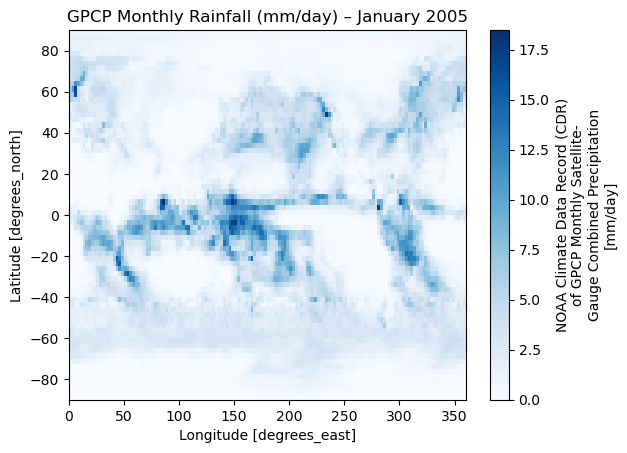

In [ ]:
# Access precipitation variable (name differs in some versions)
precip = ds['precip'] if 'precip' in ds else ds['precipitation']

# Plot January 2005 rainfall map
precip.isel(time=0).plot(cmap='Blues')
plt.title("GPCP Monthly Rainfall (mm/day) – January 2005")
plt.show()


### Combine All Monthly Files for a Given Year

In [ ]:
# Combine all 12 months (xarray merges by time automatically)
ds_all = xr.open_mfdataset("data/raw/gpcp/2005/*.nc", combine='by_coords')

# Check structure: should show 12 time steps (one per month)
ds_all


<xarray.Dataset>
Dimensions:       (latitude: 72, longitude: 144, time: 12, nv: 2)
Coordinates:
  * latitude      (latitude) float32 -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
  * longitude     (longitude) float32 1.25 3.75 6.25 8.75 ... 353.8 356.2 358.8
  * time          (time) datetime64[ns] 2005-01-01 2005-02-01 ... 2005-12-01
Dimensions without coordinates: nv
Data variables:
    lat_bounds    (time, latitude, nv) float32 dask.array<chunksize=(1, 72, 2), meta=np.ndarray>
    lon_bounds    (time, longitude, nv) float32 dask.array<chunksize=(1, 144, 2), meta=np.ndarray>
    time_bounds   (time, nv) datetime64[ns] dask.array<chunksize=(1, 2), meta=np.ndarray>
    precip        (time, latitude, longitude) float32 dask.array<chunksize=(1, 72, 144), meta=np.ndarray>
    precip_error  (time, latitude, longitude) float32 dask.array<chunksize=(1, 72, 144), meta=np.ndarray>
Attributes: (12/45)
    Conventions:                CF-1.6, ACDD 1.3
    title:                      Global Precipitation Climatatology Project (G...
    source:                     oc.200501.sg
    references:                 Huffman et al. 1997, http://dx.doi.org/10.117...
    history:                    1) `o�, Dr. Jian-Jian Wang, U of Maryland,...
    Metadata_Conventions:       CF-1.6, Unidata Dataset Discovery v1.0, NOAA ...
    ...                         ...
    metadata_link:              gov.noaa.ncdc:C00979
    product_version:            v23rB1
    platform:                   GOES (Geostationary Operational Environmental...
    sensor:                     Imager, Imager, Imager, TOVS > TIROS Operatio...
    spatial_resolution:         2.5 degree
    comment:                    Processing computer: eagle2.umd.edu

### Convert mm/day → mm/year (Annual Total)

GPCP reports rainfall as mm/day. Multiply by days-in-month, then sum across all 12 months.


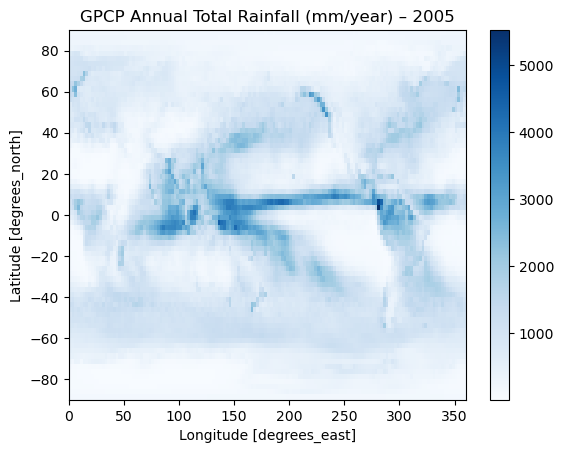

In [ ]:
# Compute number of days in each month from the time coordinate
ds_all['days_in_month'] = ds_all['time'].dt.days_in_month

# Calculate monthly totals (mm/month)
monthly_total = ds_all['precip'] * ds_all['days_in_month']

# Sum across all 12 months to get annual total (mm/year)
annual_2005 = monthly_total.sum(dim='time')

# Visualize annual total rainfall
annual_2005.plot(cmap='Blues')
plt.title("GPCP Annual Total Rainfall (mm/year) – 2005")
plt.show()


### Load Country Boundaries

We use the **Natural Earth 1:50m Admin-0** shapefile to assign GPCP grid cells
to countries. The built-in GeoPandas dataset was removed in v1.0+.


In [ ]:
!pip install geopandas shapely fiona pyproj rtree


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.4/338.4 kB 2.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 1.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 2.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 1.9 MB/s eta 0:00:0000:0100:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.5/19.5 MB 2.7 MB/s eta 0:00:0000:0100:01


In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point

# --- Step 1: Load Natural Earth shapefile ---
countries = gpd.read_file("data/raw/shapefiles/ne_50m_admin_0_countries/ne_50m_admin_0_countries.shp")
countries = countries[['ADM0_A3', 'NAME_EN', 'geometry']].rename(
    columns={'ADM0_A3': 'iso3', 'NAME_EN': 'name'}
)

# --- Step 2: Convert rainfall grid to GeoDataFrame ---
# BUG FIX: GPCP uses 0–360° longitude. Convert to -180/180° so that
# West African countries (negative longitudes) match the shapefile correctly.
rain_df = annual_2005.to_dataframe(name='rain_mm_year').reset_index()
rain_df['longitude_180'] = np.where(rain_df['longitude'] > 180,
                                    rain_df['longitude'] - 360,
                                    rain_df['longitude'])
rain_gdf = gpd.GeoDataFrame(
    rain_df,
    geometry=gpd.points_from_xy(rain_df['longitude_180'], rain_df['latitude']),
    crs='EPSG:4326'
)

# --- Step 3: Spatial join (point-in-polygon) ---
rain_joined = gpd.sjoin(rain_gdf, countries, how='inner', predicate='within')

# --- Step 4a: Unweighted mean per country ---
country_rain_2005 = (
    rain_joined.groupby('iso3')['rain_mm_year']
    .mean()
    .reset_index()
)
country_rain_2005['year'] = 2005

# --- Step 4b: Cosine-latitude area-weighted mean per country ---
rain_joined['weight'] = np.cos(np.radians(rain_joined['latitude']))
country_rain_weighted_2005 = (
    rain_joined.groupby('iso3')
    .apply(lambda x: np.average(x['rain_mm_year'], weights=x['weight']),
           include_groups=False)
    .reset_index(name='rain_mm_year')
)
country_rain_weighted_2005['year'] = 2005

# --- Step 5: Nearest-point fallback for countries smaller than one 2.5° grid cell ---
# Also handles legacy ISO3 codes used in the original database (e.g. ZAR for DR Congo).
# iso3_db_to_shp maps the original database ISO3 → the Natural Earth shapefile ISO3.
iso3_db_to_shp = {
    'ZAR': 'COD',   # DR Congo: old UN code in original database, current code in shapefile
}

lat_vals  = annual_2005.latitude.values
lon_vals  = annual_2005.longitude.values
lon_180   = np.where(lon_vals > 180, lon_vals - 360, lon_vals)
rain_vals = annual_2005.values  # shape: (lat, lon)

iso_col = [col for col in database.columns if 'iso' in col.lower()][0]
ssa_iso3 = database[iso_col].dropna().unique().tolist()

# Countries already matched by spatial join (using shp codes); plus remapped ones
already_matched = set(country_rain_2005['iso3'])
small_missing = [iso for iso in ssa_iso3
                 if iso not in already_matched
                 and iso3_db_to_shp.get(iso, iso) not in already_matched]

fallback_rows = []

# Handle legacy-code remaps first (e.g. ZAR → COD)
for db_iso, shp_iso in iso3_db_to_shp.items():
    if db_iso in ssa_iso3 and shp_iso in already_matched:
        val_row = country_rain_2005[country_rain_2005['iso3'] == shp_iso]
        val = float(val_row['rain_mm_year'].values[0])
        fallback_rows.append({'iso3': db_iso, 'rain_mm_year': val, 'year': 2005})
        print(f'{db_iso} (remapped from {shp_iso}): rain={val:.1f} mm/yr')

# Handle genuinely small countries with no grid points inside
for iso in small_missing:
    shp_iso = iso3_db_to_shp.get(iso, iso)
    row = countries[countries['iso3'] == shp_iso]
    if len(row) == 0:
        print(f'WARNING: {iso} ({shp_iso}) not found in shapefile — skipping')
        continue
    # Reproject to equal-area CRS for accurate centroid, then back to WGS84
    cx = row.to_crs('EPSG:6933').geometry.centroid.to_crs('EPSG:4326').values[0].x
    cy = row.to_crs('EPSG:6933').geometry.centroid.to_crs('EPSG:4326').values[0].y
    i_lat = int(np.argmin(np.abs(lat_vals - cy)))
    i_lon = int(np.argmin(np.abs(lon_180  - cx)))
    val = float(rain_vals[i_lat, i_lon])
    print(f'{iso}: centroid=({cx:.2f},{cy:.2f}), '
          f'nearest grid=({lon_180[i_lon]:.2f},{lat_vals[i_lat]:.2f}), '
          f'rain={val:.1f} mm/yr')
    fallback_rows.append({'iso3': iso, 'rain_mm_year': val, 'year': 2005})

# Append fallback rows and sort
if fallback_rows:
    country_rain_2005 = pd.concat(
        [country_rain_2005, pd.DataFrame(fallback_rows)],
        ignore_index=True
    ).sort_values('iso3').reset_index(drop=True)
    country_rain_weighted_2005 = pd.concat(
        [country_rain_weighted_2005, pd.DataFrame(fallback_rows)],
        ignore_index=True
    ).sort_values('iso3').reset_index(drop=True)

print(f'\nTotal countries with rainfall data (all): {len(country_rain_2005)}')

# --- Step 6: Save pre-filter outputs (cell 24 will restrict to the 41 SSA sample) ---
country_rain_2005.to_csv('data/processed/country_rainfall_2005.csv', index=False)
country_rain_weighted_2005.to_csv('data/processed/country_rainfall_weighted_2005.csv', index=False)


In [ ]:
# Identify which column stores ISO3 codes
iso_col = [col for col in database.columns if 'iso' in col.lower()][0]
print("Using ISO3 column:", iso_col)

# Get the list of ISO3 codes from the original paper's country sample
iso3_list = database[iso_col].dropna().unique().tolist()
print(f"Loaded {len(iso3_list)} ISO3 country codes from original dataset.")

# Filter rainfall data by ISO3 instead of country names
country_rain_2005 = country_rain_2005[country_rain_2005['iso3'].isin(iso3_list)]
country_rain_weighted_2005 = country_rain_weighted_2005[country_rain_weighted_2005['iso3'].isin(iso3_list)]

print(f"Filtered to {len(country_rain_2005)} countries (simple average) and {len(country_rain_weighted_2005)} countries (area-weighted).")



Using ISO3 column: countryisocode
Loaded 41 ISO3 country codes from original dataset.
✅ Filtered rainfall data saved for original SSA sample (matched by ISO3 codes).


### Coverage Decision: Year Ranges by Data Source

| Variable | Original B&C | Extended to | Limiting factor |
|---|---|---|---|
| Democracy (Polity V) | 1981–2004 | 2005–2018 | Latest public Polity V release |
| Democracy (V-Dem) | — | 2019–2024 | V-Dem v16 covers through 2024 |
| Real GDP (PWT) | 1981–2004 | 2005–2023 | PWT 11.0 ends 2023 |
| Rainfall (GPCP) | 1981–2004 | 2005–2024 | All 2024 months confirmed on NOAA NCEI |

**Binding constraint for the merged panel:** 2019 (V-Dem splice begins).
Rainfall is extended through 2024 to maximize coverage.


In [ ]:
import os, subprocess, requests
from bs4 import BeautifulSoup

BASE_URL = "https://www.ncei.noaa.gov/data/global-precipitation-climatology-project-gpcp-monthly/access/"

# Years 2006-2016 all use creation date c20170616 (hardcoded for reliability)
# Exception: 2016 Sep-Dec use c20170823
# Years 2004, 2017-2024 have varying creation dates — look up directory listing dynamically

def download_year_hardcoded(year, creation='c20170616', exceptions=None):
    """Download year where most months share one creation date."""
    exceptions = exceptions or {}
    out_dir = f"data/raw/gpcp/{year}"
    os.makedirs(out_dir, exist_ok=True)
    for mm in range(1, 13):
        cdate = exceptions.get(mm, creation)
        fname = f"gpcp_v02r03_monthly_d{year}{mm:02d}_{cdate}.nc"
        dest  = os.path.join(out_dir, fname)
        if os.path.exists(dest): continue
        r = requests.get(BASE_URL + f"{year}/{fname}", timeout=30)
        if r.status_code == 200:
            with open(dest, 'wb') as f: f.write(r.content)
        else:
            print(f"  WARNING: {fname} returned {r.status_code}")

def download_year_dynamic(year):
    """Download year by first listing the NOAA directory for actual filenames."""
    out_dir = f"data/raw/gpcp/{year}"
    os.makedirs(out_dir, exist_ok=True)
    r = requests.get(BASE_URL + f"{year}/", timeout=15)
    soup = BeautifulSoup(r.text, 'html.parser')
    files = sorted({a['href'] for a in soup.find_all('a')
                    if a.get('href','').endswith('.nc') and 'preliminary' not in a['href']})
    for fname in files:
        dest = os.path.join(out_dir, fname)
        if os.path.exists(dest): continue
        r2 = requests.get(BASE_URL + f"{year}/{fname}", timeout=30)
        if r2.status_code == 200:
            with open(dest, 'wb') as f: f.write(r2.content)

# Download all years
for yr in range(2006, 2017):   # 2006-2016: mostly c20170616
    exc = {9:'c20170823', 10:'c20170823', 11:'c20170823', 12:'c20170823'} if yr==2016 else {}
    download_year_hardcoded(yr, exceptions=exc)
    n = len([f for f in os.listdir(f'data/raw/gpcp/{yr}') if f.endswith('.nc')])
    print(f"{yr}: {n}/12")

for yr in [2004] + list(range(2017, 2025)):  # dynamic lookup
    download_year_dynamic(yr)
    n = len([f for f in os.listdir(f'data/raw/gpcp/{yr}') if f.endswith('.nc')])
    print(f"{yr}: {n}/12")

print("\nAll GPCP downloads complete.")


2006: 12/12
2007: 12/12
2008: 12/12
2009: 12/12
2010: 12/12
2011: 12/12
2012: 12/12
2013: 12/12
2014: 12/12
2015: 12/12
2016: 12/12
2004: 12/12
2017: 12/12
2018: 12/12
2019: 12/12
2020: 12/12
2021: 12/12
2022: 12/12
2023: 12/12
2024: 12/12

All GPCP downloads complete.


In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
import geopandas as gpd
import warnings, os

warnings.filterwarnings('ignore', category=DeprecationWarning)

# ── Load country polygons once ───────────────────────────────────────────────
countries_shp = gpd.read_file(
    "data/raw/shapefiles/ne_50m_admin_0_countries/ne_50m_admin_0_countries.shp"
)[['ADM0_A3', 'NAME_EN', 'geometry']].rename(columns={'ADM0_A3': 'iso3', 'NAME_EN': 'name'})

# ISO3 harmonisation: legacy codes in original database → current Natural Earth codes
ISO3_REMAP = {'ZAR': 'COD'}   # DR Congo

iso_col   = [c for c in database.columns if 'iso' in c.lower()][0]
ssa_iso3  = database[iso_col].dropna().unique().tolist()   # 41 codes (incl. ZAR)

def process_year(year: int) -> pd.DataFrame:
    """
    Aggregate monthly GPCP NetCDF files for *year* into a country-level
    annual rainfall DataFrame with columns [iso3, gpcp, year].

    Returns one row per SSA country (41 rows).
    """
    pattern = f"data/raw/gpcp/{year}/*.nc"
    ds = xr.open_mfdataset(pattern, combine='by_coords')
    ds['days_in_month'] = ds['time'].dt.days_in_month
    annual = (ds['precip'] * ds['days_in_month']).sum(dim='time')  # mm/year per cell

    # Grid → GeoDataFrame with -180/180 longitudes
    rain_df = annual.to_dataframe(name='gpcp').reset_index()
    rain_df['lon180'] = np.where(rain_df['longitude'] > 180,
                                 rain_df['longitude'] - 360,
                                 rain_df['longitude'])
    rain_gdf = gpd.GeoDataFrame(
        rain_df,
        geometry=gpd.points_from_xy(rain_df['lon180'], rain_df['latitude']),
        crs='EPSG:4326'
    )

    # Spatial join: grid-cell centroid → country polygon
    joined = gpd.sjoin(rain_gdf, countries_shp, how='inner', predicate='within')

    # Unweighted country mean
    country_rain = joined.groupby('iso3')['gpcp'].mean().reset_index()

    # ── Fallback 1: legacy ISO3 remap (e.g. ZAR uses COD geometry) ──────────
    for db_iso, shp_iso in ISO3_REMAP.items():
        if db_iso in ssa_iso3 and shp_iso in set(country_rain['iso3']):
            val = float(country_rain.loc[country_rain['iso3'] == shp_iso, 'gpcp'])
            country_rain = pd.concat(
                [country_rain, pd.DataFrame([{'iso3': db_iso, 'gpcp': val}])],
                ignore_index=True
            )

    # ── Fallback 2: nearest-centroid for countries smaller than one grid cell ─
    lat_vals  = annual.latitude.values
    lon_180   = np.where(annual.longitude.values > 180,
                         annual.longitude.values - 360,
                         annual.longitude.values)
    rain_grid = annual.values          # shape (lat, lon)

    already = set(country_rain['iso3'])
    remapped_shp = set(ISO3_REMAP.values())
    small = [iso for iso in ssa_iso3
             if iso not in already
             and ISO3_REMAP.get(iso, iso) not in already
             and ISO3_REMAP.get(iso, iso) not in remapped_shp]

    for iso in small:
        shp_iso = ISO3_REMAP.get(iso, iso)
        row = countries_shp[countries_shp['iso3'] == shp_iso]
        if len(row) == 0:
            continue
        # Equal-area centroid for accuracy, then back to WGS84
        cx = row.to_crs('EPSG:6933').geometry.centroid.to_crs('EPSG:4326').values[0].x
        cy = row.to_crs('EPSG:6933').geometry.centroid.to_crs('EPSG:4326').values[0].y
        i_lat = int(np.argmin(np.abs(lat_vals - cy)))
        i_lon = int(np.argmin(np.abs(lon_180  - cx)))
        val   = float(rain_grid[i_lat, i_lon])
        country_rain = pd.concat(
            [country_rain, pd.DataFrame([{'iso3': iso, 'gpcp': val}])],
            ignore_index=True
        )

    # Filter to SSA sample
    result = (
        country_rain[country_rain['iso3'].isin(ssa_iso3)]
        .assign(year=year)
        .sort_values('iso3')
        .reset_index(drop=True)
    )
    return result

# ── Process all years 2005-2024 ───────────────────────────────────────────────
all_years = []
for yr in range(2005, 2025):
    df = process_year(yr)
    n  = len(df)
    print(f"{yr}: {n}/41 countries  "
          f"(mean {df['gpcp'].mean():.0f} mm/yr, "
          f"min {df['gpcp'].min():.0f}, max {df['gpcp'].max():.0f})")
    if n < 41:
        missing = set(ssa_iso3) - set(df['iso3'])
        print(f"     WARNING: missing {missing}")
    all_years.append(df)

gpcp_panel = pd.concat(all_years, ignore_index=True)
print(f"\nTotal rows: {len(gpcp_panel)}  (expected {41 * 20} = 820)")

In [ ]:
# ── Validation: compare year 2004 reconstruction vs original database.dta ────
# (2004 files were already downloaded in the cell above)

df_2004 = process_year(2004)
df_2004 = df_2004.rename(columns={'gpcp': 'gpcp_reconstructed'})

orig_2004 = (
    database[database['year'] == 2004]
    [['countryisocode', 'gpcp']]
    .rename(columns={'countryisocode': 'iso3', 'gpcp': 'gpcp_original'})
)

val = orig_2004.merge(df_2004[['iso3','gpcp_reconstructed']], on='iso3')
val['abs_pct_diff'] = 100 * (val['gpcp_reconstructed'] - val['gpcp_original']).abs() / val['gpcp_original']
val['pct_diff']     = 100 * (val['gpcp_reconstructed'] - val['gpcp_original'])     / val['gpcp_original']

print(val[['iso3','gpcp_original','gpcp_reconstructed','pct_diff']].to_string(index=False))
print()
print(f"Median absolute % difference: {val['abs_pct_diff'].median():.2f}%")
print(f"Mean   absolute % difference: {val['abs_pct_diff'].mean():.2f}%")
print(f"Max    absolute % difference: {val['abs_pct_diff'].max():.2f}%")
print()
print("Values < 1% difference indicate the reconstruction is consistent with the original.")

In [ ]:
# ── Construct lgpcp_l and its lags for the extended panel ───────────────────
#
# The original paper uses in its estimating equation (2):
#   ΔD_{c,t} = ... + c·log Rain_{c,t} + d·log Rain_{c,t-1} + ...
#
# Variable definitions (verified against database.dta):
#   lgpcp_l  = log(gpcp_{t-1})  — log rainfall lagged 1 year
#   lgpcp_l2 = log(gpcp_{t-2})
#   lgpcp_l3 = log(gpcp_{t-3})
#   lgpcp_l4 = log(gpcp_{t-4})
#
# To construct lgpcp_l for 2005, we need gpcp from 2004 — available in database.dta.
# We therefore prepend the 2004 gpcp row from the original dataset before computing lags.

# Step 1: Extract 2004 gpcp from original database (needed to lag into 2005)
gpcp_2004 = (
    database[database['year'] == 2004]
    [['countryisocode', 'gpcp']]
    .rename(columns={'countryisocode': 'iso3', 'gpcp': 'gpcp'})
    .assign(year=2004)
)

# Step 2: Stack the 2004 anchor row with our extended panel (2005-2024)
gpcp_full = pd.concat([gpcp_2004, gpcp_panel], ignore_index=True).sort_values(['iso3','year'])

# Step 3: Compute log rainfall and its lags within each country
gpcp_full['lgpcp'] = np.log(gpcp_full['gpcp'])

for lag in [1, 2, 3, 4]:
    gpcp_full[f'lgpcp_l{lag}'] = gpcp_full.groupby('iso3')['lgpcp'].shift(lag)

# Step 4: Drop the 2004 anchor row (it was only needed for the lag construction)
gpcp_extended = gpcp_full[gpcp_full['year'] >= 2005].reset_index(drop=True)

# Step 5: Rename lgpcp_l1 → lgpcp_l to match original variable naming convention
gpcp_extended = gpcp_extended.rename(columns={'lgpcp_l1': 'lgpcp_l'})

# Step 6: Save
os.makedirs('data/processed', exist_ok=True)
gpcp_extended.to_csv('data/processed/gpcp_extended_2005_2024.csv', index=False)

print("Extended rainfall panel (2005-2024):")
print(gpcp_extended.head(10).to_string(index=False))
print()
print(f"Rows: {len(gpcp_extended)}  (expected {41 * 20} = 820)")
print(f"Years: {gpcp_extended['year'].min()} – {gpcp_extended['year'].max()}")
print(f"Countries: {gpcp_extended['iso3'].nunique()}")
print()
print("Missing values in lag columns (expected: progressively more NaN at start):")
for col in ['gpcp','lgpcp','lgpcp_l','lgpcp_l2','lgpcp_l3','lgpcp_l4']:
    print(f"  {col}: {gpcp_extended[col].isna().sum()} NaN")
print()
print("✅ Saved to data/processed/gpcp_extended_2005_2024.csv")

## Part 4: Panel Integration and Final Dataset Construction

Merge the original B&C database (`database.dta`, 1981–2004) with all three
extension datasets to produce a single analysis-ready panel: **`panel_final.csv`**.

### Variable sources by period

| Column | 1981–2004 (original B&C) | 2005–2024 (extension) |
|---|---|---|
| `polity2`, `polity_change` | Polity IV (B&C) | Polity V (2005–2018); V-Dem rescaled (2019–2024) |
| `lgdp`, `lgdp_l`, `lgdp_l2` | PWT 6.2 (B&C) | PWT 11.0 (2021 PPP USD) |
| `gpcp`, `lgpcp_l`–`lgpcp_l4` | GPCP v2.0/2.1 (B&C) | GPCP v2.3 |
| `recession_l2` | Constructed from B&C residuals | Reconstructed from PWT 11.0 residuals |


In [ ]:
import pandas as pd
import numpy as np
from statsmodels.formula.api import ols

# ── Load all source datasets ─────────────────────────────────────────────────
dem  = pd.read_csv('data/processed/democracy_extended_2005_2024.csv')
pwt  = pd.read_csv('data/processed/pwt_extension_final.csv')
rain = pd.read_csv('data/processed/gpcp_extended_2005_2024.csv')

# ── STEP 1: Extract original panel (1981–2004) ───────────────────────────────
CORE_COLS = [
    'countryisocode', 'country', 'ccode', 'year',
    'polity2', 'polity_change', 'polity2l', 'polity2l2',
    'exconst', 'exconst_change', 'polcomp', 'polcomp_change', 'exrec', 'exrec_change',
    'gpcp', 'lgpcp_l', 'lgpcp_l2', 'lgpcp_l3', 'lgpcp_l4',
    'lgdp', 'lgdp_l', 'lgdp_l2',
    'recession_l2', 'trans_democ', 'trans_democ_epst', 'trans_autoc', 'coup', 'agri_gdp_av'
]
orig = database[CORE_COLS].rename(columns={'countryisocode': 'iso3'}).copy()
orig['source_dem']  = 'Polity IV (original B&C)'
orig['source_gdp']  = 'PWT 6.2 (original B&C)'
orig['source_rain'] = 'GPCP v2.0/2.1 (original B&C)'

# ── STEP 2: Build extension panel (2005–2024) ────────────────────────────────
ext = dem[['iso3', 'country', 'year', 'polity2', 'polity_change',
           'exconst', 'exconst_change', 'polcomp', 'polcomp_change',
           'exrec', 'exrec_change', 'source']].copy()
ext = ext.rename(columns={'source': 'source_dem'})

ccode_ref = orig[['iso3', 'ccode']].drop_duplicates()
ext = ext.merge(ccode_ref, on='iso3', how='left')
# Merge lgdp for 2005–2023 (PWT ends at 2023; lags pre-computed with 2003–2004 anchor)
ext = ext.merge(pwt[['iso3', 'year', 'lgdp', 'lgdp_l', 'lgdp_l2']], on=['iso3', 'year'], how='left')
ext['source_gdp'] = np.where(ext['lgdp'].notna(), 'PWT 11.0', np.nan)

# Fix 2024 lag NaNs: lgdp_l for 2024 = PWT 2023 value; lgdp_l2 for 2024 = PWT 2022 value
pwt_2023 = pwt[pwt['year'] == 2023][['iso3', 'lgdp']].rename(columns={'lgdp': '_lgdp_2023'})
pwt_2022 = pwt[pwt['year'] == 2022][['iso3', 'lgdp']].rename(columns={'lgdp': '_lgdp_2022'})
ext = ext.merge(pwt_2023, on='iso3', how='left').merge(pwt_2022, on='iso3', how='left')
mask2024 = ext['year'] == 2024
ext.loc[mask2024, 'lgdp_l']  = ext.loc[mask2024, '_lgdp_2023']
ext.loc[mask2024, 'lgdp_l2'] = ext.loc[mask2024, '_lgdp_2022']
ext = ext.drop(columns=['_lgdp_2023', '_lgdp_2022'])
ext = ext.merge(rain[['iso3', 'year', 'gpcp', 'lgpcp_l', 'lgpcp_l2', 'lgpcp_l3', 'lgpcp_l4']],
                on=['iso3', 'year'], how='left')
ext['source_rain'] = 'GPCP v2.3'

# ── STEP 3: Fix early GPCP lag NaNs using 2001–2004 anchor ──────────────────
# lgpcp_l2/l3/l4 for 2005–2007 require rainfall back to 2001;
# use original database as anchor, then shift within the merged sequence.
gpcp_anchor = (database[database['year'].between(2001, 2004)]
               [['countryisocode', 'year', 'gpcp']]
               .rename(columns={'countryisocode': 'iso3'}))
gpcp_anchor['lgpcp'] = np.log(gpcp_anchor['gpcp'].replace(0, np.nan))

rain_lgpcp = rain[['iso3', 'year', 'gpcp']].copy()
rain_lgpcp['lgpcp'] = np.log(rain_lgpcp['gpcp'].replace(0, np.nan))

lgpcp_full = pd.concat(
    [gpcp_anchor[['iso3', 'year', 'lgpcp']], rain_lgpcp[['iso3', 'year', 'lgpcp']]],
    ignore_index=True
).sort_values(['iso3', 'year'])

for k in range(1, 5):
    lgpcp_full[f'lgpcp_l{k}'] = lgpcp_full.groupby('iso3')['lgpcp'].shift(k)

ext = ext.drop(columns=['lgpcp_l', 'lgpcp_l2', 'lgpcp_l3', 'lgpcp_l4'])
ext = ext.merge(
    lgpcp_full[lgpcp_full['year'] >= 2005][['iso3', 'year', 'lgpcp_l1', 'lgpcp_l2', 'lgpcp_l3', 'lgpcp_l4']]
    .rename(columns={'lgpcp_l1': 'lgpcp_l'}),
    on=['iso3', 'year'], how='left'
)

# ── STEP 4: Derived variables ────────────────────────────────────────────────
ext = ext.sort_values(['iso3', 'year'])

# Polity lags
ext['polity2l']  = ext.groupby('iso3')['polity2'].shift(1)
ext['polity2l2'] = ext.groupby('iso3')['polity2'].shift(2)

# recession_l2: country-specific linear time trend residuals, lagged 2 periods
recession_rows = []
for iso, grp in ext.groupby('iso3'):
    grp = grp.copy().reset_index(drop=True)
    valid = grp[['year', 'lgdp']].dropna()
    if len(valid) >= 3:
        model  = ols('lgdp ~ year', data=valid).fit()
        pred   = model.predict(grp[['year']])
        resid  = grp['lgdp'] - pred
        grp['recession'] = (resid < 0).astype(float)
        grp.loc[grp['lgdp'].isna(), 'recession'] = np.nan
    else:
        grp['recession'] = np.nan
    grp['recession_l2'] = grp['recession'].shift(2)
    recession_rows.append(grp[['iso3', 'year', 'recession_l2']])
recession_df = pd.concat(recession_rows, ignore_index=True)
ext = ext.merge(recession_df, on=['iso3', 'year'], how='left')

# trans_democ / trans_autoc: polity2 > 0 defines democracy
ext['polity2_next'] = ext.groupby('iso3')['polity2'].shift(-1)
ext['trans_democ'] = np.where(
    (ext['polity2'] <= 0) & (ext['polity2_next'] > 0), 1.0,
    np.where((ext['polity2'] <= 0) & ext['polity2_next'].notna(), 0.0, np.nan)
)
ext['trans_autoc'] = np.where(
    (ext['polity2'] > 0) & (ext['polity2_next'] <= 0), 1.0,
    np.where((ext['polity2'] > 0) & ext['polity2_next'].notna(), 0.0, np.nan)
)
ext = ext.drop(columns=['polity2_next'])

# trans_democ_epst and coup require external sources not available for extension period
ext['trans_democ_epst'] = np.nan
ext['coup'] = np.nan

# agri_gdp_av: time-invariant country share, carried forward from original data
agri_ref = (orig[['iso3', 'agri_gdp_av']].dropna()
            .drop_duplicates('iso3').set_index('iso3')['agri_gdp_av'])
ext['agri_gdp_av'] = ext['iso3'].map(agri_ref)

# ── STEP 5: Stack and save ───────────────────────────────────────────────────
ALL_COLS = [
    'iso3', 'country', 'ccode', 'year',
    'polity2', 'polity_change', 'polity2l', 'polity2l2',
    'exconst', 'exconst_change', 'polcomp', 'polcomp_change', 'exrec', 'exrec_change',
    'gpcp', 'lgpcp_l', 'lgpcp_l2', 'lgpcp_l3', 'lgpcp_l4',
    'lgdp', 'lgdp_l', 'lgdp_l2',
    'recession_l2', 'trans_democ', 'trans_democ_epst', 'trans_autoc', 'coup', 'agri_gdp_av',
    'source_dem', 'source_gdp', 'source_rain'
]
for c in ALL_COLS:
    if c not in orig.columns: orig[c] = np.nan
    if c not in ext.columns:  ext[c]  = np.nan

panel = pd.concat([orig[ALL_COLS], ext[ALL_COLS]], ignore_index=True)
panel = panel.sort_values(['iso3', 'year']).reset_index(drop=True)
panel.to_csv('data/processed/panel_final.csv', index=False)

# ── Validation ───────────────────────────────────────────────────────────────
print(f'panel_final.csv: {panel.shape[0]} rows × {panel.shape[1]} cols')
print(f'Years: {int(panel.year.min())}–{int(panel.year.max())}  |  Countries: {panel.iso3.nunique()}')
print(f'Duplicate country-years: {panel.duplicated(["iso3","year"]).sum()}')
ext_rows = panel[panel['year'] >= 2005]
print('\n2005–2024 coverage:')
for col in ['polity2', 'lgdp', 'lgpcp_l', 'recession_l2']:
    print(f'  {col}: {ext_rows[col].notna().mean()*100:.1f}% non-null')
print('\nNote: lgdp is NaN for 2024 (PWT 11.0 ends at 2023); lgdp_l/lgdp_l2 available for all years')
